In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load your dataset
data = pd.read_csv('./solar_radiation.csv')

# Convert month to numeric values
month_mapping = {month: idx for idx, month in enumerate(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])}
data['month'] = data['month'].map(month_mapping)

# Verify month column
print(data['month'].unique())  # Should show values from 0 to 11

# Normalize Features
features = ['H(h)_m', 'H(i_opt)_m', 'H(i)_m', 'Hb(n)_m', 'Kd', 'T2m']
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Define target variable and features
X = data[['H(h)_m', 'H(i_opt)_m', 'H(i)_m', 'Hb(n)_m', 'Kd', 'T2m', 'month']]
y = data['H(h)_m']  # Replace with your actual target column name

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

[ 0  1  2  3  4  5  6  7  8  9 10 11]


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, LayerNormalization, MultiHeadAttention, Dropout, Flatten, Concatenate, Reshape, GlobalAveragePooling1D
from tensorflow.keras.models import Model

def build_transformer_model(input_shape):
    # Define inputs
    feature_inputs = Input(shape=input_shape, name='features')
    month_inputs = Input(shape=(1,), dtype='int32', name='month')
    
    # Embedding layer for month
    month_embedding = Embedding(input_dim=12, output_dim=8)(month_inputs)
    
    # Flatten the month embedding to be concatenated
    month_embedding = Flatten()(month_embedding)
    
    # Combine numerical features with month embeddings
    x = Concatenate()([feature_inputs, month_embedding])
    
    # Adding a transformer-like block
    x = Dense(128, activation='relu')(x)
    x = LayerNormalization()(x)
    x = Reshape((1, -1))(x)  # Reshape for MultiHeadAttention
    
    attention_output = MultiHeadAttention(
        num_heads=8,
        key_dim=64
    )(query=x, value=x, key=x)  # Using query, key, and value as x

    x = Dropout(0.1)(attention_output)
    x = Dense(64, activation='relu')(x)
    x = GlobalAveragePooling1D()(x)  # Ensure x is 3D for this layer
    x = Dense(1)(x)
    
    model = Model(inputs=[feature_inputs, month_inputs], outputs=x)
    model.compile(optimizer='adam', loss='mse')
    
    return model

# Define model input shapes
input_shape = (X_train.shape[1] - 1, )  # Exclude month column
model = build_transformer_model(input_shape)

In [3]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=10)
]

# Ensure the month column in X_train and X_test are of integer type
X_train['month'] = X_train['month'].astype(np.int32)
X_test['month'] = X_test['month'].astype(np.int32)

history = model.fit(
    [X_train.drop(columns='month'), X_train['month']],
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/50


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.4220 - val_loss: 0.0896 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0653 - val_loss: 0.0125 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0254 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0190 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0195 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 6/50


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0187 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0139 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0131 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0117 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0091 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0102 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0075 - val_loss: 0.0044 - learning_rate: 2.0000e-04
Epoch 13/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0047 - val_loss: 0.0016 - learning_rate: 2.0000e-04
Epoch 14/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0065 - val_loss: 0.0014 - learning_rate: 2.0000e-04
Epoch 15/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [4]:
test_loss = model.evaluate([X_test.drop(columns='month'), X_test['month']], y_test)
print(f'Test Loss: {test_loss}')

predictions = model.predict([X_test.drop(columns='month'), X_test['month']])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.1487e-04 
Test Loss: 0.0009153707069344819
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


In [5]:
# Make predictions on the test set
y_pred = model.predict([X_test.drop(columns='month'), X_test['month']])

# Show the first few predictions and actual values
import pandas as pd

# Combine predictions and actual values for comparison
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred.flatten()
})

print(results.head())

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
       Actual  Predicted
45   0.405780   0.442422
136  0.874167   0.861758
76   0.911049   0.873961
143  0.079575   0.100335
113  0.756625   0.757098


In [6]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate Mean Absolute Error and R-squared
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")

Mean Absolute Error: 0.02494804990143741
R-squared: 0.9859635365568739


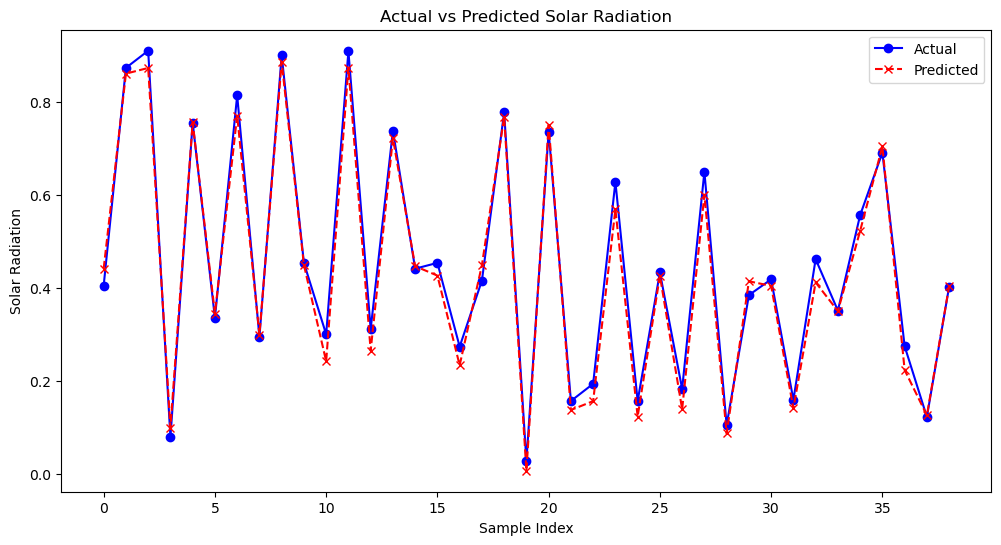

In [7]:
import matplotlib.pyplot as plt

# Plotting Actual vs Predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(y_pred, label='Predicted', color='red', linestyle='--', marker='x')
plt.xlabel('Sample Index')
plt.ylabel('Solar Radiation')
plt.title('Actual vs Predicted Solar Radiation')
plt.legend()
plt.show()

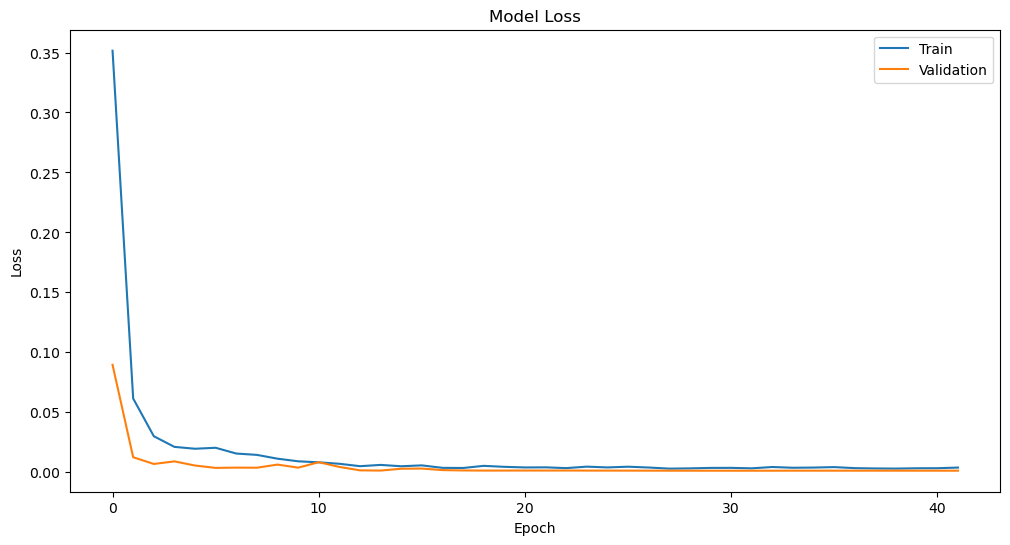

In [8]:
# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# OTHER MODELS

## TYPE 1 COMPARISON

## CNN

In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv1D, Flatten, Embedding, Concatenate, Dropout, Reshape, GlobalAveragePooling1D
from tensorflow.keras.models import Model

def build_cnn_model(input_shape):
    # Define inputs
    feature_inputs = Input(shape=input_shape, name='features')
    month_inputs = Input(shape=(1,), dtype='int32', name='month')

    # Embedding layer for month
    month_embedding = Embedding(input_dim=12, output_dim=8)(month_inputs)
    month_embedding = Flatten()(month_embedding)

    # Combine numerical features with month embeddings
    x = Concatenate()([feature_inputs, month_embedding])

    # CNN layers
    x = Reshape((x.shape[1], 1))(x)  # Reshape for Conv1D
    x = Conv1D(filters=64, kernel_size=2, activation='relu')(x)
    x = Conv1D(filters=32, kernel_size=2, activation='relu')(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.2)(x)
    
    # Output layer
    output = Dense(1)(x)

    model = Model(inputs=[feature_inputs, month_inputs], outputs=output)
    model.compile(optimizer='adam', loss='mse')

    return model

# Define model input shapes
input_shape = (X_train.shape[1] - 1,)  # Exclude month column
cnn_model = build_cnn_model(input_shape)

# Train the CNN model
cnn_history = cnn_model.fit(
    [X_train.drop(columns='month'), X_train['month']],
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

# Evaluate the CNN model
cnn_test_loss = cnn_model.evaluate([X_test.drop(columns='month'), X_test['month']], y_test)
print(f'CNN Test Loss: {cnn_test_loss}')


Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2008 - val_loss: 0.1458 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1408 - val_loss: 0.1050 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1180 - val_loss: 0.0725 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0771 - val_loss: 0.0560 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0532 - val_loss: 0.0579 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0652 - val_loss: 0.0617 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0659 - val_loss: 0.0578 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0592 - val_loss: 0.0522 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0558 - val_loss: 0.0498 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/

## RNN

In [10]:
from tensorflow.keras.layers import SimpleRNN

def build_rnn_model(input_shape):
    # Define inputs
    feature_inputs = Input(shape=input_shape, name='features')
    month_inputs = Input(shape=(1,), dtype='int32', name='month')

    # Embedding layer for month
    month_embedding = Embedding(input_dim=12, output_dim=8)(month_inputs)
    month_embedding = Flatten()(month_embedding)

    # Combine numerical features with month embeddings
    x = Concatenate()([feature_inputs, month_embedding])

    # RNN layer
    x = Reshape((x.shape[1], 1))(x)  # Reshape for RNN
    x = SimpleRNN(64, return_sequences=False, activation='relu')(x)
    x = Dropout(0.2)(x)
    
    # Output layer
    output = Dense(1)(x)

    model = Model(inputs=[feature_inputs, month_inputs], outputs=output)
    model.compile(optimizer='adam', loss='mse')

    return model

# Define model input shapes
rnn_model = build_rnn_model(input_shape)

# Train the RNN model
rnn_history = rnn_model.fit(
    [X_train.drop(columns='month'), X_train['month']],
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

# Evaluate the RNN model
rnn_test_loss = rnn_model.evaluate([X_test.drop(columns='month'), X_test['month']], y_test)
print(f'RNN Test Loss: {rnn_test_loss}')


Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.2300 - val_loss: 0.1957 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2150 - val_loss: 0.1600 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1463 - val_loss: 0.0994 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0894 - val_loss: 0.0533 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0834 - val_loss: 0.0496 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0525 - val_loss: 0.0422 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0536 - val_loss: 0.0361 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0452 - val_loss: 0.0281 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0299 - val_loss: 0.0251 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/s

## LSTM

In [11]:
from tensorflow.keras.layers import LSTM

def build_lstm_model(input_shape):
    # Define inputs
    feature_inputs = Input(shape=input_shape, name='features')
    month_inputs = Input(shape=(1,), dtype='int32', name='month')

    # Embedding layer for month
    month_embedding = Embedding(input_dim=12, output_dim=8)(month_inputs)
    month_embedding = Flatten()(month_embedding)

    # Combine numerical features with month embeddings
    x = Concatenate()([feature_inputs, month_embedding])

    # LSTM layer
    x = Reshape((x.shape[1], 1))(x)  # Reshape for LSTM
    x = LSTM(64, return_sequences=False, activation='relu')(x)
    x = Dropout(0.2)(x)
    
    # Output layer
    output = Dense(1)(x)

    model = Model(inputs=[feature_inputs, month_inputs], outputs=output)
    model.compile(optimizer='adam', loss='mse')

    return model

# Define model input shapes
lstm_model = build_lstm_model(input_shape)

# Train the LSTM model
lstm_history = lstm_model.fit(
    [X_train.drop(columns='month'), X_train['month']],
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

# Evaluate the LSTM model
lstm_test_loss = lstm_model.evaluate([X_test.drop(columns='month'), X_test['month']], y_test)
print(f'LSTM Test Loss: {lstm_test_loss}')


Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.2271 - val_loss: 0.1929 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2103 - val_loss: 0.1654 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1710 - val_loss: 0.1311 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1318 - val_loss: 0.0888 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0841 - val_loss: 0.0535 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0606 - val_loss: 0.0743 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0677 - val_loss: 0.0553 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0573 - val_loss: 0.0525 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0626 - val_loss: 0.0530 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/s

## Model COMPARISON

In [12]:
from sklearn.metrics import mean_absolute_error, r2_score

# CNN Predictions
cnn_y_pred = cnn_model.predict([X_test.drop(columns='month'), X_test['month']])
cnn_mae = mean_absolute_error(y_test, cnn_y_pred)
cnn_r2 = r2_score(y_test, cnn_y_pred)

# RNN Predictions
rnn_y_pred = rnn_model.predict([X_test.drop(columns='month'), X_test['month']])
rnn_mae = mean_absolute_error(y_test, rnn_y_pred)
rnn_r2 = r2_score(y_test, rnn_y_pred)

# LSTM Predictions
lstm_y_pred = lstm_model.predict([X_test.drop(columns='month'), X_test['month']])
lstm_mae = mean_absolute_error(y_test, lstm_y_pred)
lstm_r2 = r2_score(y_test, lstm_y_pred)

print(f'CNN MAE: {cnn_mae}, CNN R-squared: {cnn_r2}')
print(f'RNN MAE: {rnn_mae}, RNN R-squared: {rnn_r2}')
print(f'LSTM MAE: {lstm_mae}, LSTM R-squared: {lstm_r2}')


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/stepWARNING:tensorflow:6 out of the last 8 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x30127e830> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
CNN MAE: 0.17192875900166504, CNN R-squared: 0.27635195273389224
RNN MAE: 0.11113694866553495, RNN R-squared: 0.7386725262168408
L

## PLOT COMPARISON

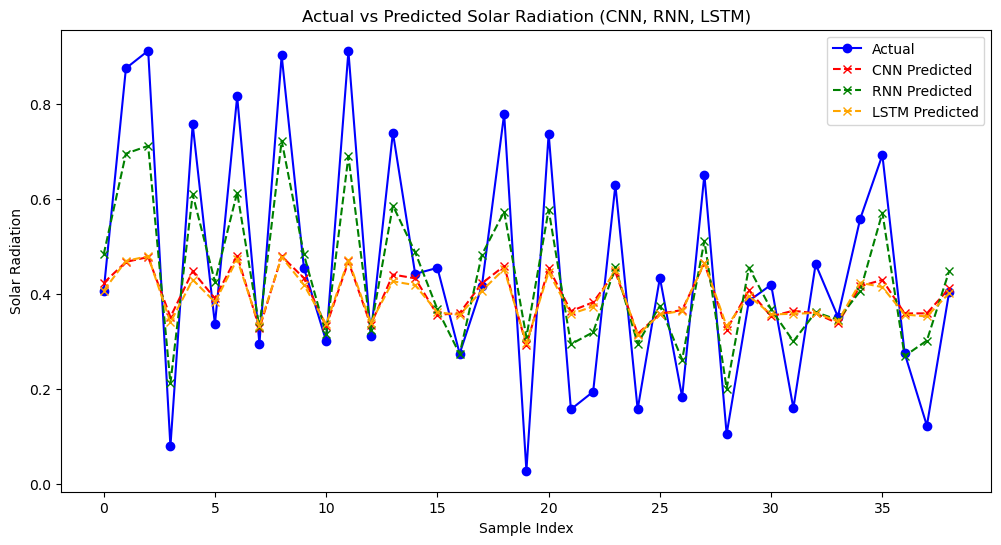

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')

# CNN Plot
plt.plot(cnn_y_pred, label='CNN Predicted', color='red', linestyle='--', marker='x')

# RNN Plot
plt.plot(rnn_y_pred, label='RNN Predicted', color='green', linestyle='--', marker='x')

# LSTM Plot
plt.plot(lstm_y_pred, label='LSTM Predicted', color='orange', linestyle='--', marker='x')

plt.xlabel('Sample Index')
plt.ylabel('Solar Radiation')
plt.title('Actual vs Predicted Solar Radiation (CNN, RNN, LSTM)')
plt.legend()
plt.show()


## HYBRID MODELS

### CNN+RNN

In [14]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, SimpleRNN, Input, Dense, Reshape
from tensorflow.keras.models import Model

def build_cnn_rnn_model(input_shape):
    # Input layer for numerical features
    feature_inputs = Input(shape=input_shape, name='features')
    
    # Reshape the input to add a time dimension (needed for Conv1D)
    x = Reshape((input_shape[0], 1))(feature_inputs)  # Reshape to (batch_size, features, 1)
    
    # CNN layers
    x = Conv1D(filters=64, kernel_size=3, activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    
    # RNN layer
    x = SimpleRNN(64, activation='relu', return_sequences=False)(x)
    
    # Dense layer
    x = Dense(32, activation='relu')(x)
    
    # Output layer
    output = Dense(1)(x)
    
    model = Model(inputs=feature_inputs, outputs=output)
    model.compile(optimizer='adam', loss='mse')
    
    return model

# Build and train the CNN + RNN model
cnn_rnn_model = build_cnn_rnn_model((X_train.shape[1] - 1,))  # X_train without 'month'
cnn_rnn_history = cnn_rnn_model.fit(
    X_train.drop(columns='month'), 
    y_train,
    epochs=50, 
    batch_size=32, 
    validation_split=0.2, 
    callbacks=callbacks
)



Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.2074 - val_loss: 0.1282 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1200 - val_loss: 0.0744 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0836 - val_loss: 0.0551 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0615 - val_loss: 0.0600 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0602 - val_loss: 0.0578 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0531 - val_loss: 0.0469 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0459 - val_loss: 0.0416 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0462 - val_loss: 0.0381 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0380 - val_loss: 0.0330 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/s

## CNN + LSTM

In [15]:
from tensorflow.keras.layers import LSTM

def build_cnn_lstm_model(input_shape):
    # Input layer for numerical features
    feature_inputs = Input(shape=input_shape, name='features')
    
    # Reshape the input to add a time dimension (needed for Conv1D)
    x = Reshape((input_shape[0], 1))(feature_inputs)  # Reshape to (batch_size, features, 1)
    
    # CNN layers
    x = Conv1D(filters=64, kernel_size=3, activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    
    # LSTM layer
    x = LSTM(64, activation='relu', return_sequences=False)(x)
    
    # Dense layer
    x = Dense(32, activation='relu')(x)
    
    # Output layer
    output = Dense(1)(x)
    
    model = Model(inputs=feature_inputs, outputs=output)
    model.compile(optimizer='adam', loss='mse')
    
    return model

# Build and train the CNN + LSTM model
cnn_lstm_model = build_cnn_lstm_model((X_train.shape[1] - 1,))  # X_train without 'month'
cnn_lstm_history = cnn_lstm_model.fit(
    X_train.drop(columns='month'),
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.2294 - val_loss: 0.1703 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1697 - val_loss: 0.1349 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1327 - val_loss: 0.0962 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1054 - val_loss: 0.0656 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0690 - val_loss: 0.0573 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0610 - val_loss: 0.0673 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0635 - val_loss: 0.0650 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0585 - val_loss: 0.0561 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0593 - val_loss: 0.0536 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/s

## CNN+RNN+LSTM

In [16]:
def build_cnn_rnn_lstm_model(input_shape):
    # Input layer for numerical features
    feature_inputs = Input(shape=input_shape, name='features')
    
    # Reshape the input to add a time dimension (needed for Conv1D)
    x = Reshape((input_shape[0], 1))(feature_inputs)  # Reshape to (batch_size, features, 1)
    
    # CNN layers
    x = Conv1D(filters=64, kernel_size=3, activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    
    # RNN layer
    x = SimpleRNN(64, activation='relu', return_sequences=True)(x)
    
    # LSTM layer
    x = LSTM(64, activation='relu', return_sequences=False)(x)
    
    # Dense layer
    x = Dense(32, activation='relu')(x)
    
    # Output layer
    output = Dense(1)(x)
    
    model = Model(inputs=feature_inputs, outputs=output)
    model.compile(optimizer='adam', loss='mse')
    
    return model

# Build and train the CNN + RNN + LSTM model
cnn_rnn_lstm_model = build_cnn_rnn_lstm_model((X_train.shape[1] - 1,))  # X_train without 'month'
cnn_rnn_lstm_history = cnn_rnn_lstm_model.fit(
    X_train.drop(columns='month'),
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.2393 - val_loss: 0.1808 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1884 - val_loss: 0.1337 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1192 - val_loss: 0.0874 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0766 - val_loss: 0.0587 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0730 - val_loss: 0.0698 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0738 - val_loss: 0.0671 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0672 - val_loss: 0.0549 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0619 - val_loss: 0.0528 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0574 - val_loss: 0.0516 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/s

## COMPARISON

In [17]:
# CNN + RNN Evaluation
cnn_rnn_y_pred = cnn_rnn_model.predict(X_test.drop(columns='month'))
cnn_rnn_mae = mean_absolute_error(y_test, cnn_rnn_y_pred)
cnn_rnn_r2 = r2_score(y_test, cnn_rnn_y_pred)

# CNN + LSTM Evaluation
cnn_lstm_y_pred = cnn_lstm_model.predict(X_test.drop(columns='month'))
cnn_lstm_mae = mean_absolute_error(y_test, cnn_lstm_y_pred)
cnn_lstm_r2 = r2_score(y_test, cnn_lstm_y_pred)

# CNN + RNN + LSTM Evaluation
cnn_rnn_lstm_y_pred = cnn_rnn_lstm_model.predict(X_test.drop(columns='month'))
cnn_rnn_lstm_mae = mean_absolute_error(y_test, cnn_rnn_lstm_y_pred)
cnn_rnn_lstm_r2 = r2_score(y_test, cnn_rnn_lstm_y_pred)

# Print the results
print(f'CNN + RNN MAE: {cnn_rnn_mae}, R-squared: {cnn_rnn_r2}')
print(f'CNN + LSTM MAE: {cnn_lstm_mae}, R-squared: {cnn_lstm_r2}')
print(f'CNN + RNN + LSTM MAE: {cnn_rnn_lstm_mae}, R-squared: {cnn_rnn_lstm_r2}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
CNN + RNN MAE: 0.12727703955190195, R-squared: 0.6303990959884986
CNN + LSTM MAE: 0.18412486908003986, R-squared: 0.18060586640366372
CNN + RNN + LSTM MAE: 0.17636482286812624, R-squared: 0.2813328374097376


## PLOT

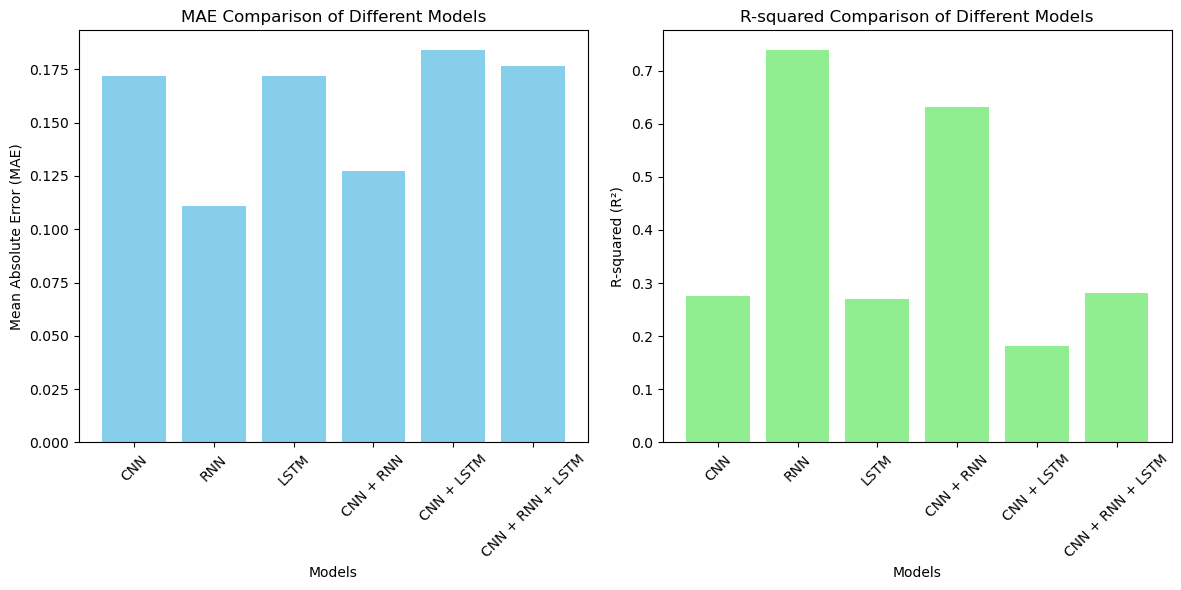

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Storing the results for each model
model_names = ['CNN', 'RNN', 'LSTM', 'CNN + RNN', 'CNN + LSTM', 'CNN + RNN + LSTM']
mae_scores = [cnn_mae, rnn_mae, lstm_mae, cnn_rnn_mae, cnn_lstm_mae, cnn_rnn_lstm_mae]
r2_scores = [cnn_r2, rnn_r2, lstm_r2, cnn_rnn_r2, cnn_lstm_r2, cnn_rnn_lstm_r2]

# Setting up the bar positions for better visibility
x_pos = np.arange(len(model_names))

# Plotting the MAE scores
plt.figure(figsize=(12, 6))

# Subplot 1: MAE
plt.subplot(1, 2, 1)
plt.bar(x_pos, mae_scores, color='skyblue')
plt.xticks(x_pos, model_names, rotation=45)
plt.xlabel('Models')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('MAE Comparison of Different Models')

# Subplot 2: R-squared
plt.subplot(1, 2, 2)
plt.bar(x_pos, r2_scores, color='lightgreen')
plt.xticks(x_pos, model_names, rotation=45)
plt.xlabel('Models')
plt.ylabel('R-squared (R²)')
plt.title('R-squared Comparison of Different Models')

# Display the plots
plt.tight_layout()
plt.show()

# TYPE 2 ( OF COMPARISON)

In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, LayerNormalization, MultiHeadAttention, Dropout, Flatten, Concatenate, Reshape, GlobalAveragePooling1D, Conv1D, MaxPooling1D, SimpleRNN, LSTM
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load your dataset
data = pd.read_csv('./solar_radiation.csv')

# Convert month to numeric values
month_mapping = {month: idx for idx, month in enumerate(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])}
data['month'] = data['month'].map(month_mapping)

# Normalize Features
features = ['H(h)_m', 'H(i_opt)_m', 'H(i)_m', 'Hb(n)_m', 'Kd', 'T2m']
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Define target variable and features
X = data[['H(h)_m', 'H(i_opt)_m', 'H(i)_m', 'Hb(n)_m', 'Kd', 'T2m', 'month']]
y = data['H(h)_m']  # Replace with your actual target column name

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape for CNN, RNN, and LSTM models
X_train_reshaped = X_train.drop(columns='month').values.reshape(X_train.shape[0], X_train.shape[1]-1, 1)
X_test_reshaped = X_test.drop(columns='month').values.reshape(X_test.shape[0], X_test.shape[1]-1, 1)

# Callbacks for early stopping and learning rate reduction
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
]

## CNN MODEL

In [21]:
def build_cnn_model(input_shape):
    model = tf.keras.Sequential([
        Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

cnn_model = build_cnn_model((X_train_reshaped.shape[1], 1))
history_cnn = cnn_model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=callbacks)
y_pred_cnn = cnn_model.predict(X_test_reshaped)

Epoch 1/50


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2085 - val_loss: 0.0972 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0940 - val_loss: 0.0605 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0678 - val_loss: 0.0619 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0646 - val_loss: 0.0611 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0671 - val_loss: 0.0509 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0568 - val_loss: 0.0434 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0447 - val_loss: 0.0393 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0456 - val_loss: 0.0352 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0380 - val_loss: 0.0298 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss:

## RNN MODEL

In [22]:
def build_rnn_model(input_shape):
    model = tf.keras.Sequential([
        SimpleRNN(64, input_shape=input_shape),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

rnn_model = build_rnn_model((X_train_reshaped.shape[1], 1))
history_rnn = rnn_model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=callbacks)
y_pred_rnn = rnn_model.predict(X_test_reshaped)

Epoch 1/50


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2375 - val_loss: 0.0553 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0533 - val_loss: 0.0343 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0300 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0190 - val_loss: 0.0118 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0107 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0065 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0020 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0024 - val_loss: 9.9628e-04 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0012 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - l

## LSTM MODEL

In [23]:
def build_lstm_model(input_shape):
    model = tf.keras.Sequential([
        LSTM(64, input_shape=input_shape),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_model = build_lstm_model((X_train_reshaped.shape[1], 1))
history_lstm = lstm_model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=callbacks)
y_pred_lstm = lstm_model.predict(X_test_reshaped)


Epoch 1/50


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1810 - val_loss: 0.1263 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1184 - val_loss: 0.0839 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0614 - val_loss: 0.0531 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0480 - val_loss: 0.0462 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0500 - val_loss: 0.0544 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0482 - val_loss: 0.0475 - learning_rate: 0.0010
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0432 - val_loss: 0.0423 - learning_rate: 0.0010
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0465 - val_loss: 0.0425 - learning_rate: 0.0010
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0484 - val_loss: 0.0397 - learning_rate: 0.0010
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss:

## PERFORMANCE METRICS 

CNN - MAE: 0.008521021985901975, R2: 0.998210263115067
RNN - MAE: 0.021182895788430512, R2: 0.9854075037278637
LSTM - MAE: 0.15585871634677945, R2: 0.4813760250600442
Transformer - MAE: 0.02494804990143741, R2: 0.9859635365568739


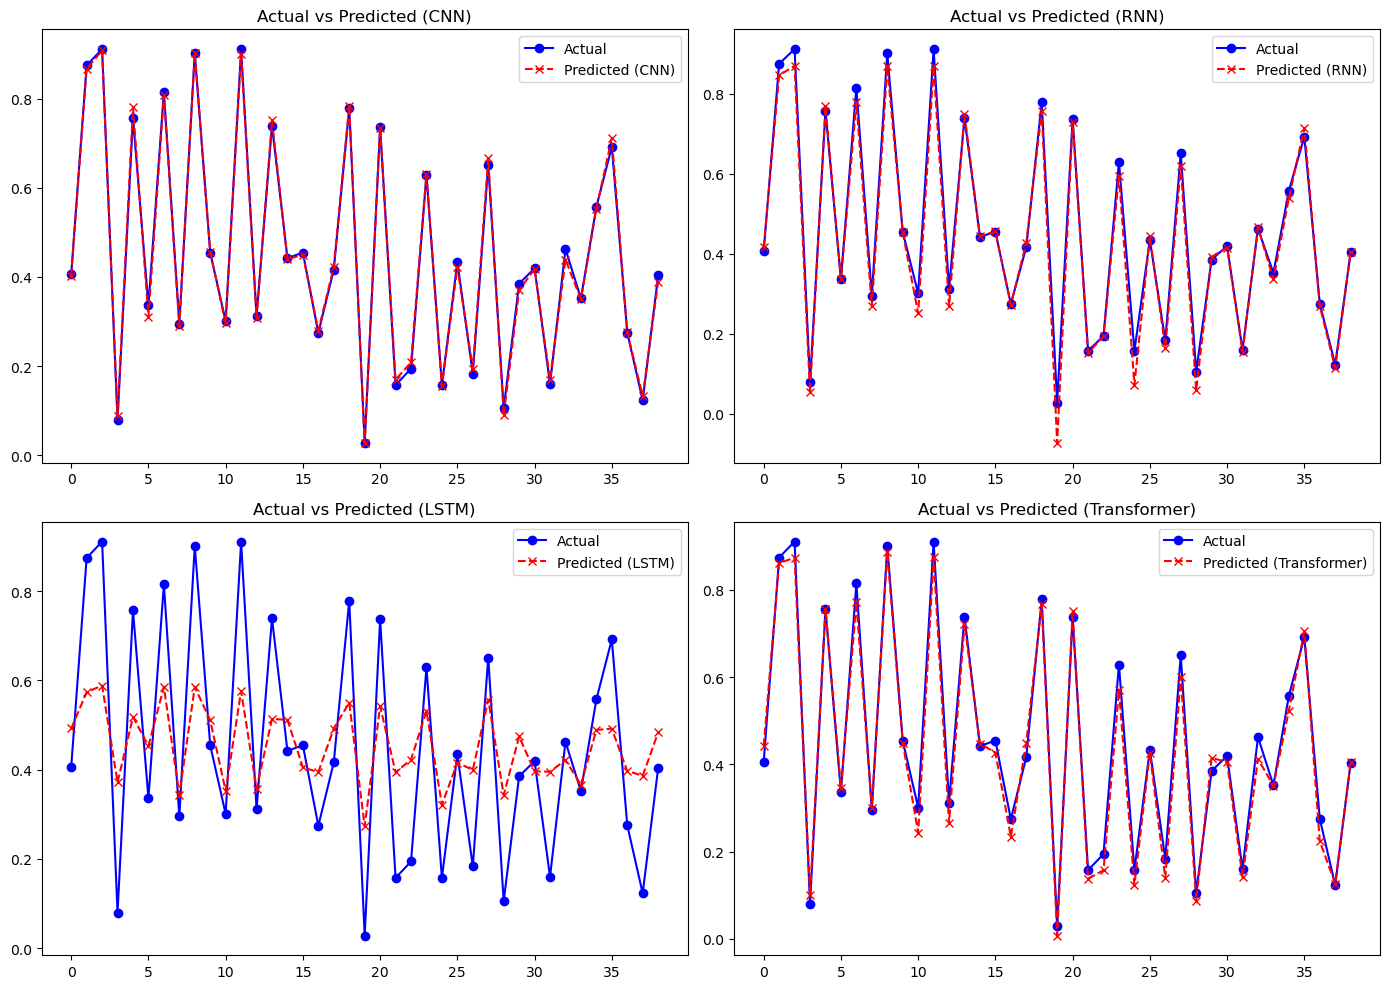

In [24]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, r2

# Calculate evaluation metrics for each model
mae_cnn, r2_cnn = evaluate_model(y_test, y_pred_cnn)
mae_rnn, r2_rnn = evaluate_model(y_test, y_pred_rnn)
mae_lstm, r2_lstm = evaluate_model(y_test, y_pred_lstm)
mae_transformer, r2_transformer = evaluate_model(y_test, y_pred)

# Print results
print(f"CNN - MAE: {mae_cnn}, R2: {r2_cnn}")
print(f"RNN - MAE: {mae_rnn}, R2: {r2_rnn}")
print(f"LSTM - MAE: {mae_lstm}, R2: {r2_lstm}")
print(f"Transformer - MAE: {mae_transformer}, R2: {r2_transformer}")

# Plotting Actual vs Predicted for all models
plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(y_pred_cnn, label='Predicted (CNN)', color='red', linestyle='--', marker='x')
plt.title('Actual vs Predicted (CNN)')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(y_pred_rnn, label='Predicted (RNN)', color='red', linestyle='--', marker='x')
plt.title('Actual vs Predicted (RNN)')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(y_pred_lstm, label='Predicted (LSTM)', color='red', linestyle='--', marker='x')
plt.title('Actual vs Predicted (LSTM)')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(y_test.values, label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(y_pred, label='Predicted (Transformer)', color='red', linestyle='--', marker='x')
plt.title('Actual vs Predicted (Transformer)')
plt.legend()

plt.tight_layout()
plt.show()

# HYBRID WITH CNN

## 1) CNN-LSTM

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, LSTM, Dense, Dropout

def build_cnn_lstm_model(input_shape):
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(50))  # Adding LSTM layer
    model.add(Dense(1))  # Output layer
    model.compile(optimizer='adam', loss='mse')
    return model


## 2) CNN-RNN

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, SimpleRNN, Dense

def build_cnn_rnn_model(input_shape):
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(SimpleRNN(50))  # Adding RNN layer
    model.add(Dense(1))  # Output layer
    model.compile(optimizer='adam', loss='mse')
    return model


## 3) CNN-Transformer

In [27]:
def build_cnn_transformer_model(input_shape):
    feature_inputs = Input(shape=input_shape, name='features')
    
    # CNN layers
    x = Conv1D(filters=64, kernel_size=2, activation='relu')(feature_inputs)
    x = MaxPooling1D(pool_size=2)(x)
    x = Flatten()(x)
    
    # Transformer block
    x = Reshape((1, -1))(x)  # Reshape for MultiHeadAttention
    attention_output = MultiHeadAttention(num_heads=8, key_dim=64)(query=x, value=x, key=x)
    x = Flatten()(attention_output)
    
    x = Dense(1)(x)  # Output layer
    model = Model(inputs=feature_inputs, outputs=x)
    model.compile(optimizer='adam', loss='mse')
    
    return model


## COMPARISON

/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


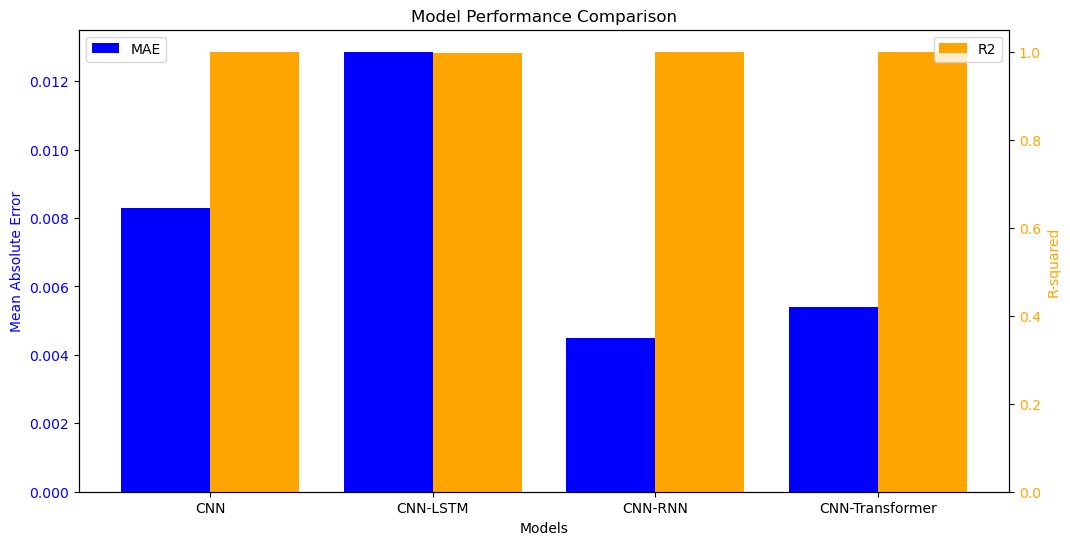

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# Define input shape for the models
input_shape = (X_train.shape[1] - 1, 1)  # Reshape for Conv1D
X_train_reshaped = X_train.drop(columns='month').values.reshape(-1, input_shape[0], 1)
X_test_reshaped = X_test.drop(columns='month').values.reshape(-1, input_shape[0], 1)

# Train the models
models = {
    'CNN': build_cnn_model(input_shape),
    'CNN-LSTM': build_cnn_lstm_model(input_shape),
    'CNN-RNN': build_cnn_rnn_model(input_shape),
    'CNN-Transformer': build_cnn_transformer_model(input_shape),
}

results = {}

for model_name, model in models.items():
    history = model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[model_name] = {'MAE': mae, 'R2': r2}

# Plotting the results
labels = list(results.keys())
mae_values = [results[label]['MAE'] for label in labels]
r2_values = [results[label]['R2'] for label in labels]

x = np.arange(len(labels))

fig, ax1 = plt.subplots(figsize=(12, 6))

# Create bar graph for MAE
ax1.bar(x - 0.2, mae_values, 0.4, label='MAE', color='blue')
ax1.set_ylabel('Mean Absolute Error', color='blue')
ax1.set_xlabel('Models')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for R2 values
ax2 = ax1.twinx()
ax2.bar(x + 0.2, r2_values, 0.4, label='R2', color='orange')
ax2.set_ylabel('R-squared', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Adding title and legend
plt.title('Model Performance Comparison')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

## COMPARISON PART 2

/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
CNN - MAE: 0.006241, R²: 0.999120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
CNN-LSTM - MAE: 0.009656, R²: 0.997487
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
CNN-RNN - MAE: 0.006995, R²: 0.998913


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
CNN-Transformer - MAE: 0.004012, R²: 0.999575


/Users/apple/Desktop/sample_project/env/lib/python3.10/site-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


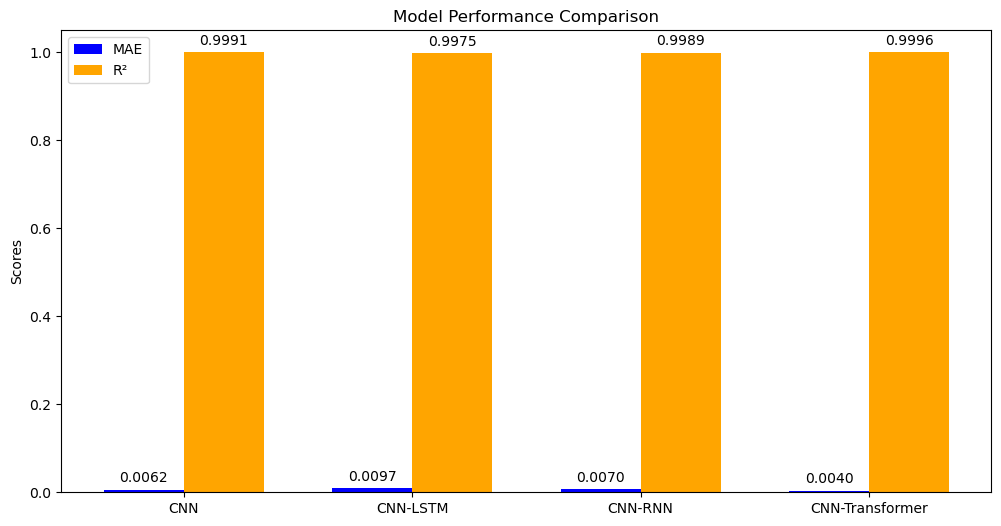

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# Define input shape for the models
input_shape = (X_train.shape[1] - 1, 1)  # Reshape for Conv1D
X_train_reshaped = X_train.drop(columns='month').values.reshape(-1, input_shape[0], 1)
X_test_reshaped = X_test.drop(columns='month').values.reshape(-1, input_shape[0], 1)

# Train the models
models = {
    'CNN': build_cnn_model(input_shape),
    'CNN-LSTM': build_cnn_lstm_model(input_shape),
    'CNN-RNN': build_cnn_rnn_model(input_shape),
    'CNN-Transformer': build_cnn_transformer_model(input_shape),
}

results = {}

for model_name, model in models.items():
    # Fit the model
    history = model.fit(X_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
    y_pred = model.predict(X_test_reshaped)
    
    # Calculate performance metrics
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[model_name] = {'MAE': mae, 'R2': r2}
    
    # Print the performance metrics for each model
    print(f"{model_name} - MAE: {mae:.6f}, R²: {r2:.6f}")

# Preparing data for plotting
labels = list(results.keys())
mae_values = [results[label]['MAE'] for label in labels]
r2_values = [results[label]['R2'] for label in labels]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, mae_values, width, label='MAE', color='blue')
bars2 = ax.bar(x + width/2, r2_values, width, label='R²', color='orange')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Function to annotate bars
def autolabel(bars):
    """Attach a text label above each bar in *bars*, displaying its height."""
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(bars1)
autolabel(bars2)

plt.show()
